In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("data/sentiment", exist_ok=True)

tickers = [
    "AAPL", "MSFT", "GOOGL", "META", "AMZN", "NFLX", "TSLA", "ABNB",
    "NVDA", "AMD", "INTC", "QCOM", "AVGO", "MU", "ARM", "AMAT",
    "V", "MA", "PYPL", "COIN", "HOOD",
    "JPM", "GS", "BAC", "WFC", "MS", "BLK",
    "CRM", "NOW", "SNOW", "PLTR", "NET", "DDOG", "MDB",
    "WMT", "TGT", "COST", "EBAY", "SHOP",
    "UNH", "ISRG", "DXCM",
    "ENPH", "FSLR", "RIVN"
]
print(f"股票数量: {len(tickers)}")

股票数量: 45


In [2]:
import os

FORCE_VADER = False
USE_FINBERT = False

if not FORCE_VADER:
    try:
        from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

        local_path = "./models/finbert"  # 换成你实际存放的路径
        print("开始加载 FinBERT（本地文件），请稍候...")

        tokenizer = AutoTokenizer.from_pretrained(local_path)
        model = AutoModelForSequenceClassification.from_pretrained(local_path)

        sentiment_pipeline = pipeline(
            "text-classification",
            model=model,
            tokenizer=tokenizer,
            device=-1
        )
        USE_FINBERT = True
        print("FinBERT 加载成功")
    except Exception as e:
        print(f"FinBERT 加载失败: {e}")
        print("自动切换到 VADER")

if not USE_FINBERT:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    vader = SentimentIntensityAnalyzer()
    print("VADER 已就绪")

开始加载 FinBERT（本地文件），请稍候...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT 加载成功


In [3]:
label_map = {"positive": 1, "negative": -1, "neutral": 0}

def analyze_sentiment(texts, batch_size=16):
    results = []
    if USE_FINBERT:
        for i in range(0, len(texts), batch_size):
            batch = [str(x)[:512] for x in texts[i:i+batch_size]]
            try:
                preds = sentiment_pipeline(batch)
                results.extend(preds)
            except Exception as e:
                print(f"Batch {i} 出错: {e}")
                results.extend([{"label": "neutral", "score": 0.5}] * len(batch))
    else:
        for text in texts:
            score = vader.polarity_scores(str(text))["compound"]
            if score > 0.05:
                results.append({"label": "positive", "score": score})
            elif score < -0.05:
                results.append({"label": "negative", "score": abs(score)})
            else:
                results.append({"label": "neutral", "score": 0.5})
    return results

print(f"情感分析引擎: {'FinBERT' if USE_FINBERT else 'VADER'}")

情感分析引擎: FinBERT


In [4]:
df_news = pd.read_csv("data/news/all_news.csv")
print(f"总计 {len(df_news)} 条新闻，开始分析...")

headlines = df_news["headline"].fillna("").tolist()
results = analyze_sentiment(headlines)

df_news["sentiment_label"] = [r["label"] for r in results]
df_news["sentiment_score"] = [r["score"] for r in results]
df_news["sentiment_numeric"] = df_news["sentiment_label"].map(label_map)

print(f"分析引擎: {'FinBERT' if USE_FINBERT else 'VADER'}")
print(f"情感分布:\n{df_news['sentiment_label'].value_counts()}")
df_news[["ticker", "headline", "sentiment_label", "sentiment_numeric"]].head()

总计 4899 条新闻，开始分析...
分析引擎: FinBERT
情感分布:
sentiment_label
neutral     2477
positive    1302
negative    1120
Name: count, dtype: int64


,ticker,headline,sentiment_label,sentiment_numeric
0,AAPL,"LGBTQ consumers cut spending at Target, Walmar...",negative,-1
1,AAPL,"Apple Investors Are Tired of AI Promises, Want...",neutral,0
2,AAPL,Apple Looks Beyond the iPhone Upgrade Cycle,neutral,0
3,AAPL,Intel Is Fast-Tracking Its Next Upgrade. It Co...,positive,1
4,AAPL,"Apple Eyes AI-Powered AirPods, Foldable iPhone...",neutral,0


In [5]:
df_news.to_csv("data/sentiment/news_with_sentiment.csv", index=False)

summary_rows = []
for ticker in tickers:
    df_t = df_news[df_news["ticker"] == ticker]
    if len(df_t) == 0:
        continue
    summary_rows.append({
        "ticker": ticker,
        "total_articles": len(df_t),
        "positive_ratio": (df_t["sentiment_label"] == "positive").mean(),
        "negative_ratio": (df_t["sentiment_label"] == "negative").mean(),
        "neutral_ratio": (df_t["sentiment_label"] == "neutral").mean(),
        "avg_sentiment": df_t["sentiment_numeric"].mean()
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv("data/sentiment/sentiment_summary.csv", index=False)
print(df_summary[["ticker", "total_articles", "avg_sentiment"]].to_string())

   ticker  total_articles  avg_sentiment
0    AAPL             110       0.009091
1    MSFT             110       0.000000
2   GOOGL             110       0.027273
3    META             110      -0.027273
4    AMZN             110       0.136364
5    NFLX             109      -0.174312
6    TSLA             109       0.100917
7    ABNB             109       0.055046
8    NVDA             109       0.192661
9     AMD             110       0.227273
10   INTC             110       0.227273
11   QCOM             110       0.036364
12   AVGO             110       0.027273
13     MU             107       0.130841
14    ARM             109      -0.073394
15   AMAT             104       0.201923
16      V             109       0.000000
17     MA             110       0.036364
18   PYPL             109      -0.036697
19   COIN             109      -0.036697
20   HOOD             106      -0.132075
21    JPM             110      -0.009091
22     GS             110       0.054545
23    BAC       

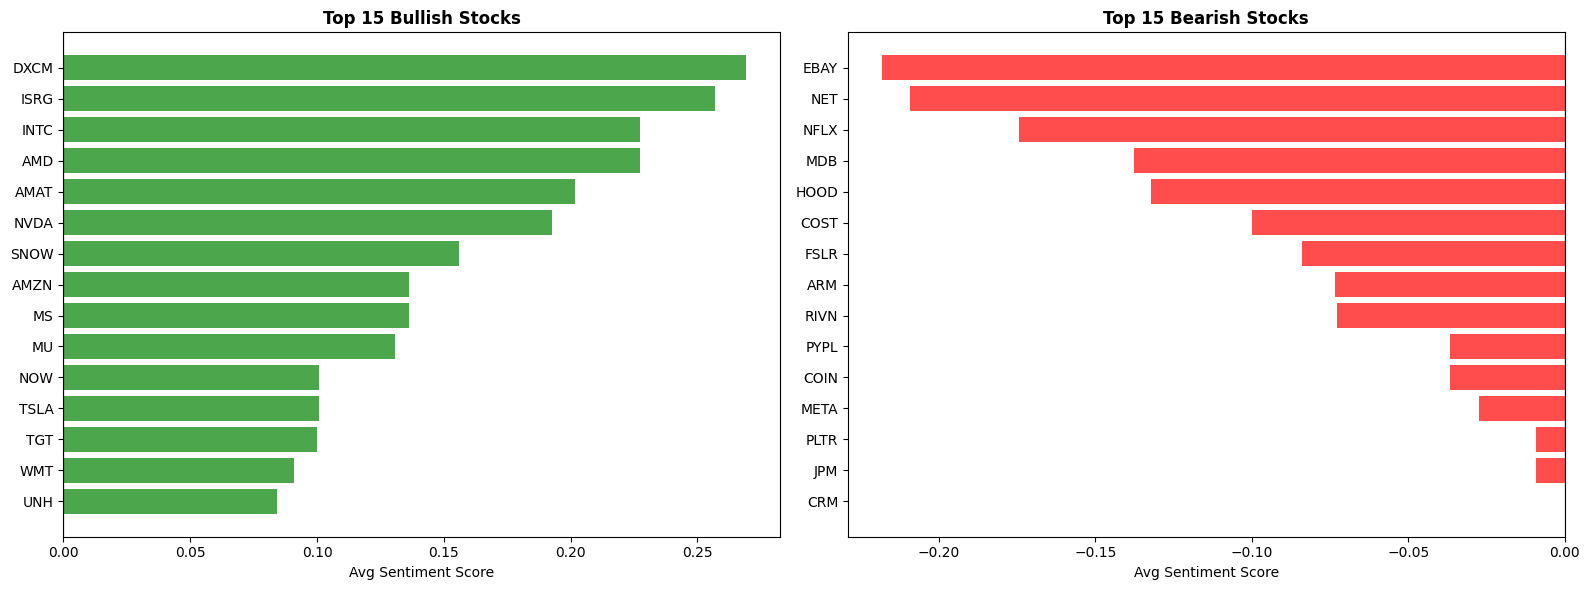

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avg = df_summary.set_index("ticker")["avg_sentiment"].sort_values(ascending=False)
top_pos = avg.head(15)
top_neg = avg.tail(15)

axes[0].barh(top_pos.index[::-1], top_pos.values[::-1], color="green", alpha=0.7)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Top 15 Bullish Stocks", fontweight="bold")
axes[0].set_xlabel("Avg Sentiment Score")

axes[1].barh(top_neg.index, top_neg.values, color="red", alpha=0.7)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Top 15 Bearish Stocks", fontweight="bold")
axes[1].set_xlabel("Avg Sentiment Score")

plt.tight_layout()
plt.savefig("data/sentiment/sentiment_overview.png", dpi=150)
plt.show()

In [7]:
def SentimentTool(ticker: str) -> dict:
    """
    Agent Tool: 返回指定股票情感分析结果
    Input:  ticker (str) 如 'NVDA'
    Output: dict with sentiment summary
    """
    df = pd.read_csv("data/sentiment/news_with_sentiment.csv")
    df_t = df[df["ticker"] == ticker]

    if len(df_t) == 0:
        return {"error": f"No news data found for {ticker}"}

    mean_score = float(df_t["sentiment_numeric"].mean())
    signal = "BULLISH" if mean_score > 0.1 else "BEARISH" if mean_score < -0.1 else "NEUTRAL"

    return {
        "ticker": ticker,
        "total_articles": len(df_t),
        "avg_sentiment_score": round(mean_score, 3),
        "positive_ratio": round(float((df_t["sentiment_label"] == "positive").mean()), 3),
        "negative_ratio": round(float((df_t["sentiment_label"] == "negative").mean()), 3),
        "overall_signal": signal,
        "model_used": "FinBERT" if USE_FINBERT else "VADER",
        "sample_headlines": df_t["headline"].head(3).tolist()
    }

# 测试
print(SentimentTool("NVDA"))
print()
print(SentimentTool("TSLA"))

{'ticker': 'NVDA', 'total_articles': 109, 'avg_sentiment_score': 0.193, 'positive_ratio': 0.367, 'negative_ratio': 0.174, 'overall_signal': 'BULLISH', 'model_used': 'FinBERT', 'sample_headlines': ["Intel's 18A-P chips are in production and just in time as CPU demand ramps up", 'SpaceX Shares Fall for First Time Since Blockbuster Debut', "Is Micron Stock's Data Center Engine Stalling, Or Just Drowned Out By AI?"]}

{'ticker': 'TSLA', 'total_articles': 109, 'avg_sentiment_score': 0.101, 'positive_ratio': 0.284, 'negative_ratio': 0.183, 'overall_signal': 'BULLISH', 'model_used': 'FinBERT', 'sample_headlines': ["China's Brutal Auto Price War Claims Its Biggest Victim Yet: BMW", 'Tesla needs to deliver on Robotaxi milestones for shares to find momentum: analyst', 'Microsoft dips below 200-day moving average: Buy, hold, or sell?']}


In [8]:
print("=== Week 6 Sentiment Analysis Report ===")
print(f"Total news analyzed: {len(df_news)}")
print(f"Stocks covered: {df_news['ticker'].nunique()}")
print(f"Model used: {'FinBERT' if USE_FINBERT else 'VADER'}")
print()

top15 = df_summary.sort_values("avg_sentiment", ascending=False).head(15)
print("Top 15 Bullish Stocks:")
print(top15[["ticker", "total_articles", "avg_sentiment"]].to_string(index=False))
print()

print("All stocks SentimentTool test:")
for ticker in tickers[:10]:
    r = SentimentTool(ticker)
    print(f"  {ticker}: {r['overall_signal']} | avg={r['avg_sentiment_score']}")

=== Week 6 Sentiment Analysis Report ===
Total news analyzed: 4899
Stocks covered: 45
Model used: FinBERT

Top 15 Bullish Stocks:
ticker  total_articles  avg_sentiment
  DXCM             104       0.269231
  ISRG             105       0.257143
  INTC             110       0.227273
   AMD             110       0.227273
  AMAT             104       0.201923
  NVDA             109       0.192661
  SNOW             109       0.155963
  AMZN             110       0.136364
    MS             110       0.136364
    MU             107       0.130841
   NOW             109       0.100917
  TSLA             109       0.100917
   TGT             110       0.100000
   WMT             110       0.090909
   UNH             107       0.084112

All stocks SentimentTool test:
  AAPL: NEUTRAL | avg=0.009
  MSFT: NEUTRAL | avg=0.0
  GOOGL: NEUTRAL | avg=0.027
  META: NEUTRAL | avg=-0.027
  AMZN: BULLISH | avg=0.136
  NFLX: BEARISH | avg=-0.174
  TSLA: BULLISH | avg=0.101
  ABNB: NEUTRAL | avg=0.055
  NVD